In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [28]:
X, y = make_classification(
    
    n_samples=2000,
    
    n_features=2,
    
    n_redundant=0,
    
    n_informative=2,
    
    n_clusters_per_class=1,
    
    class_sep=1.2,
    
    random_state=42
)

print(X.shape)

(2000, 2)


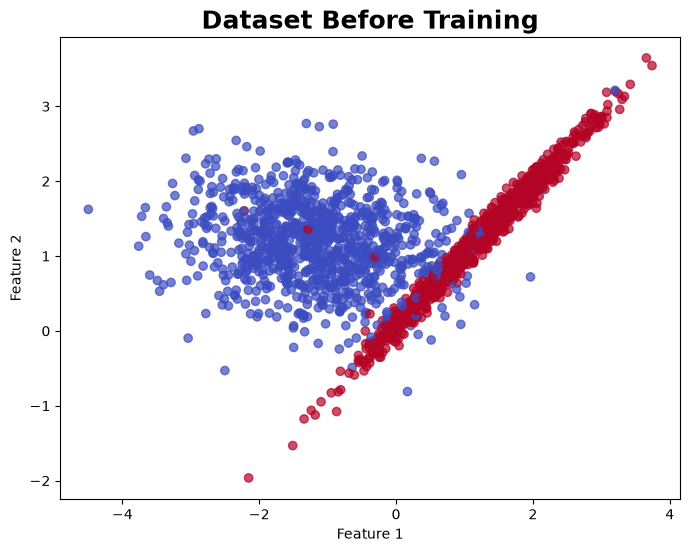

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    
    X[:,0],
    
    X[:,1],
    
    c=y,
    
    cmap='coolwarm',
    
    alpha=0.7
)

plt.title(
    
    "Dataset Before Training",
    
    fontsize=18,
    
    fontweight='bold'
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    
    y,
    
    test_size=0.3,
    
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [42]:
C_values = [0.01, 0.1, 1, 10, 100,]

models = {}

accuracies = []

support_vectors = []

In [43]:
for c in C_values:
    
    svm = SVC(
        
        kernel="linear",
        
        C=c
    )
    
    svm.fit(
        
        X_train_scaled,
        
        y_train
    )
    
    pred = svm.predict(
        
        X_test_scaled
    )
    
    acc = accuracy_score(
        
        y_test,
        
        pred
    )
    
    models[c] = svm
    
    accuracies.append(acc)
    
    support_vectors.append(
        
        len(svm.support_vectors_)
    )
    
    print(
        
        f"C = {c} | Accuracy = {acc:.4f}"
    )

C = 0.01 | Accuracy = 0.9067
C = 0.1 | Accuracy = 0.8933
C = 1 | Accuracy = 0.8867
C = 10 | Accuracy = 0.8867
C = 100 | Accuracy = 0.8867


In [44]:
results = pd.DataFrame({
    
    "C Value": C_values,
    
    "Accuracy": accuracies,
    
    "Support Vectors": support_vectors
})

results

,C Value,Accuracy,Support Vectors
0,0.01,0.906667,229
1,0.10,0.893333,122
2,1.00,0.886667,88
3,10.00,0.886667,80
4,100.00,0.886667,79


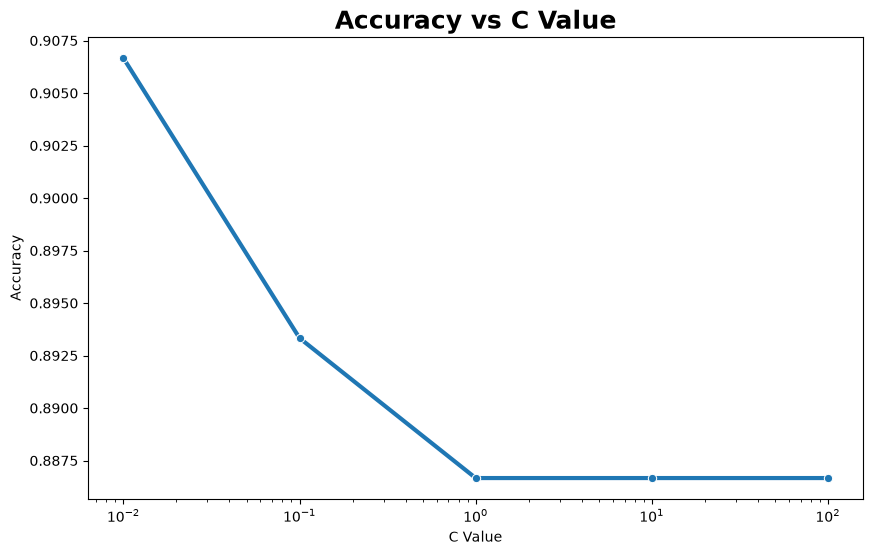

In [45]:
plt.figure(figsize=(10,6))

sns.lineplot(
    
    x=C_values,
    
    y=accuracies,
    
    marker="o",
    
    linewidth=3
)

plt.xscale("log")

plt.title(
    
    "Accuracy vs C Value",
    
    fontsize=18,
    
    fontweight="bold"
)

plt.xlabel("C Value")

plt.ylabel("Accuracy")

plt.show()

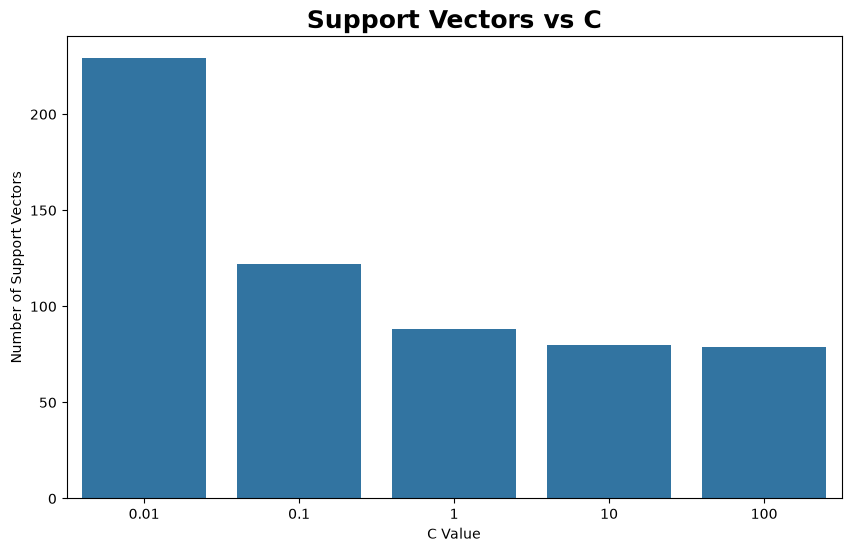

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    
    x=[str(i) for i in C_values],
    
    y=support_vectors
)

plt.title(
    
    "Support Vectors vs C",
    
    fontsize=18,
    
    fontweight="bold"
)

plt.xlabel("C Value")

plt.ylabel("Number of Support Vectors")

plt.show()

In [47]:
def plot_boundary(model,
                  X,
                  y,
                  title):
    
    x_min = X[:,0].min() - 1
    
    x_max = X[:,0].max() + 1
    
    y_min = X[:,1].min() - 1
    
    y_max = X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        
        np.linspace(x_min,x_max,500),
        
        np.linspace(y_min,y_max,500)
    )
    
    Z = model.predict(
        
        np.c_[xx.ravel(),
              yy.ravel()]
    )
    
    Z = Z.reshape(xx.shape)
    
    plt.contourf(
        
        xx,
        
        yy,
        
        Z,
        
        alpha=0.25,
        
        cmap="coolwarm"
    )
    
    plt.scatter(
        
        X[:,0],
        
        X[:,1],
        
        c=y,
        
        cmap="coolwarm",
        
        edgecolors="black",
        
        alpha=0.7
    )
    
    plt.scatter(
        
        model.support_vectors_[:,0],
        
        model.support_vectors_[:,1],
        
        s=180,
        
        facecolors='yellow',
        
        edgecolors='black',
        
        linewidth=2,
        
        label="Support Vectors"
    )
    
    plt.title(
        
        title,
        
        fontsize=16,
        
        fontweight="bold"
    )
    
    plt.legend()

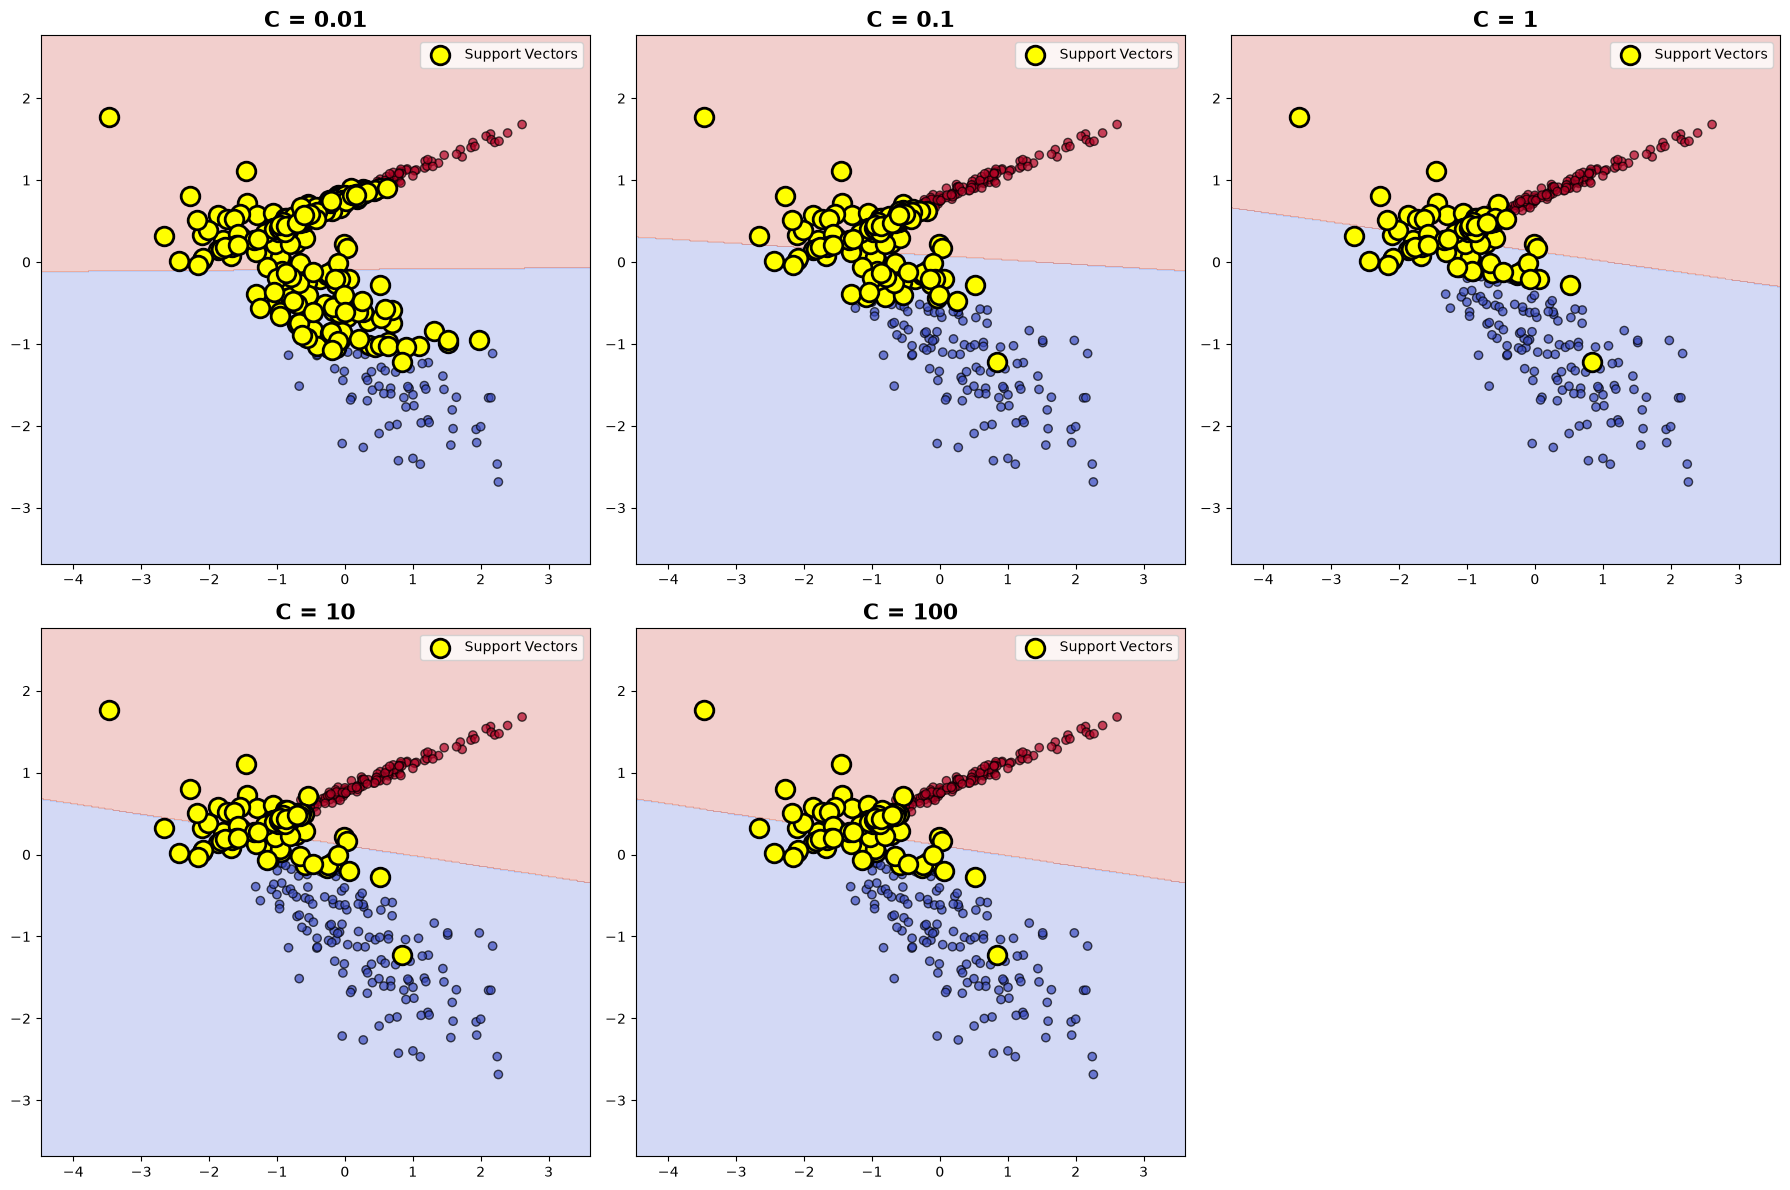

In [48]:
fig, axes = plt.subplots(
    
    2,
    
    3,
    
    figsize=(18,12)
)

axes = axes.ravel()

for i,c in enumerate(C_values):
    
    plt.sca(
        
        axes[i]
    )
    
    plot_boundary(
        
        models[c],
        
        X_train_scaled,
        
        y_train,
        
        f"C = {c}"
    )

axes[-1].axis("off")

plt.tight_layout()

plt.show()

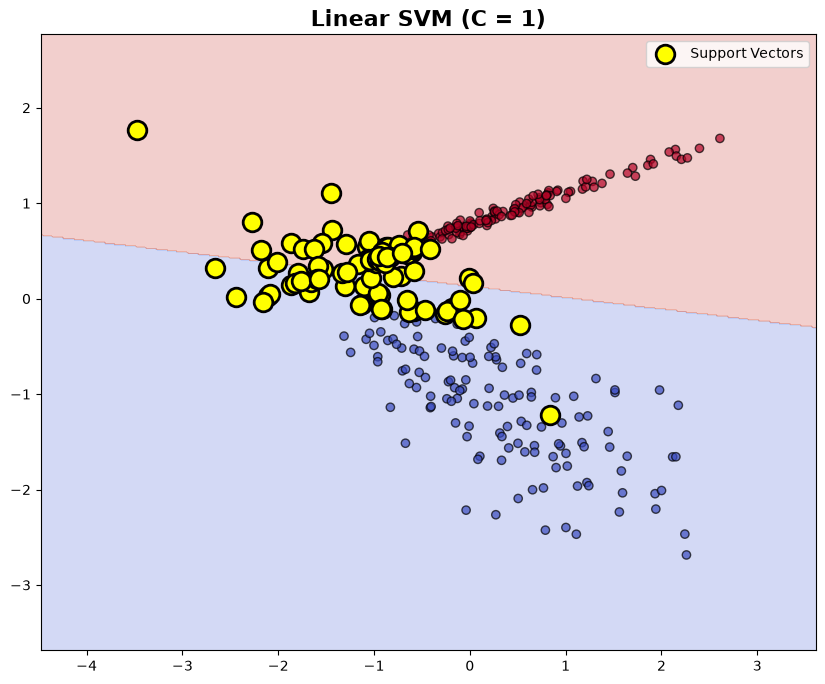

In [27]:
best_model = models[1]

plt.figure(figsize=(10,8))

plot_boundary(
    
    best_model,
    
    X_train_scaled,
    
    y_train,
    
    "Linear SVM (C = 1)"
)

plt.show()